# Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labeling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

# Init

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

c:\python37\lib\site-packages\tqdm\std.py:668: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  from pandas import Panel


# Load Data

In [4]:
df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews.sample(5)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
8973,tt0451109,movie,Dark Harvest II: The Maize,The Maize: The Movie,2004,\N,100,0,Horror,1.9,2577,"This is by far the worst ever 'horror' movie, ...",1,neg,0,test,4189
18850,tt0348949,tvSeries,Joe Millionaire,Joe Millionaire,2003,2003,60,0,"Game-Show,Reality-TV,Romance",2.5,386,You loose 100 IQ points just for tuning in. Th...,1,neg,0,train,4428
26631,tt0876563,movie,Ponyo,Gake no ue no Ponyo,2008,\N,101,0,"Adventure,Animation,Comedy",7.7,118145,Said to be inspired from Disney's The Little M...,7,pos,1,test,5296
33718,tt0111383,movie,Teenage Exorcist,Teenage Exorcist,1991,\N,86,0,"Comedy,Horror",5.1,292,Teenage Exorcist is one of those God-awful fil...,3,neg,0,test,9757
23717,tt0479500,movie,Nancy Drew,Nancy Drew,2007,\N,99,0,"Comedy,Crime,Family",5.9,19004,It's a refreshing breath of air when a movie a...,10,pos,1,train,6553


In [6]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

# EDA

Let's check number of movies and reviews over years.

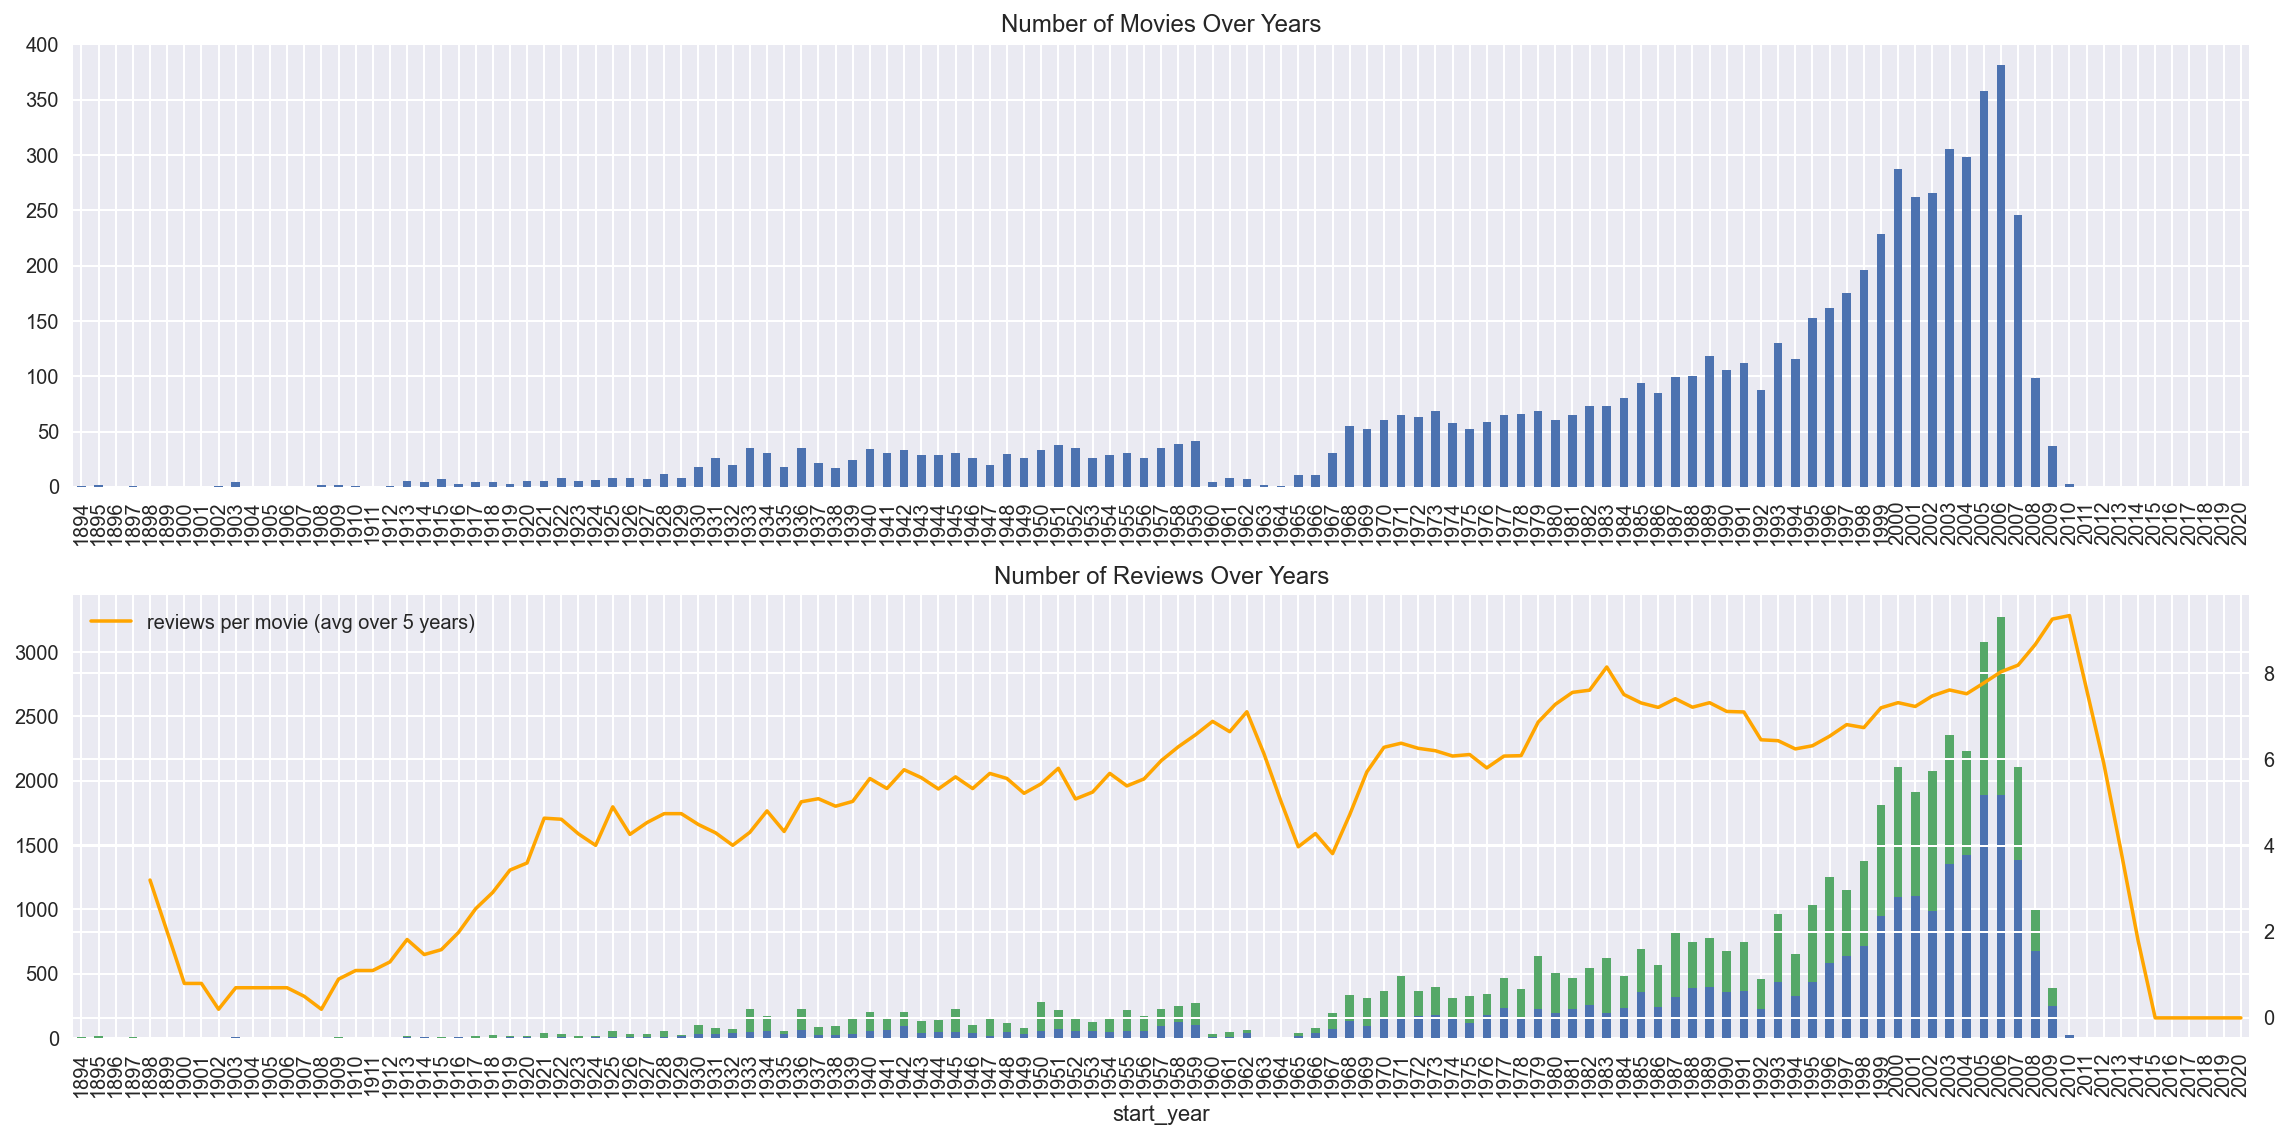

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

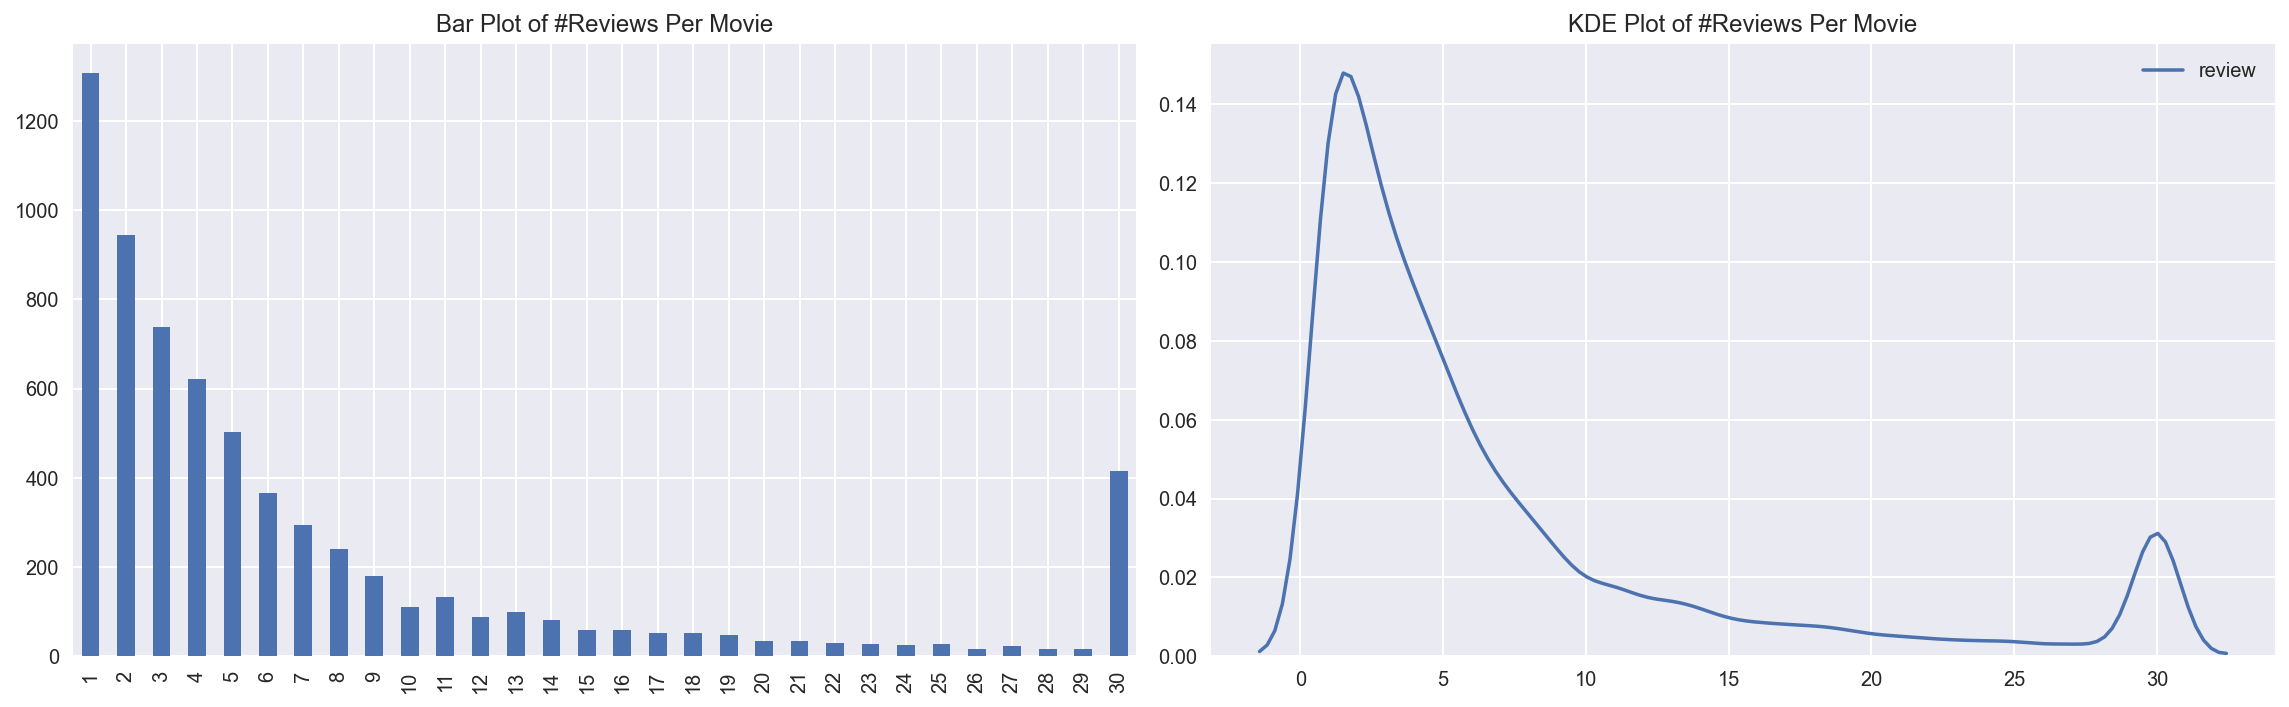

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [7]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

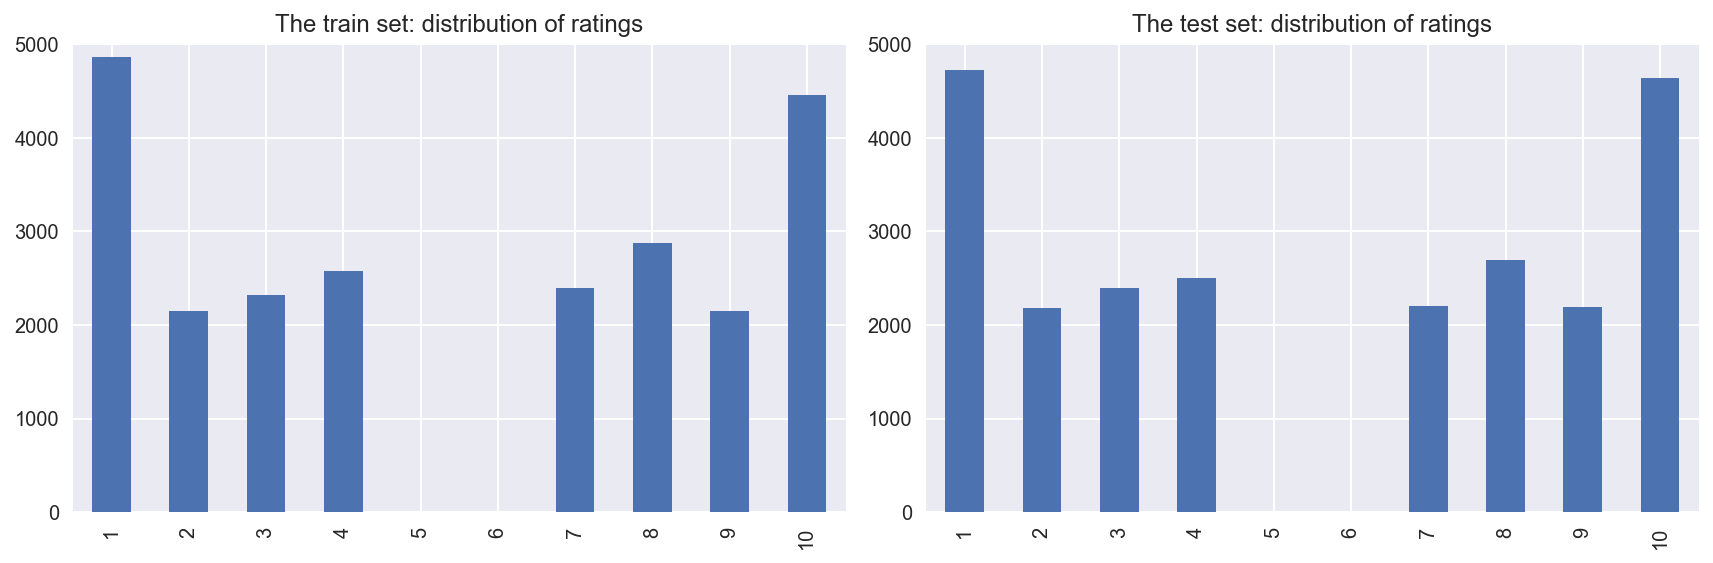

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over years for two parts of the dataset

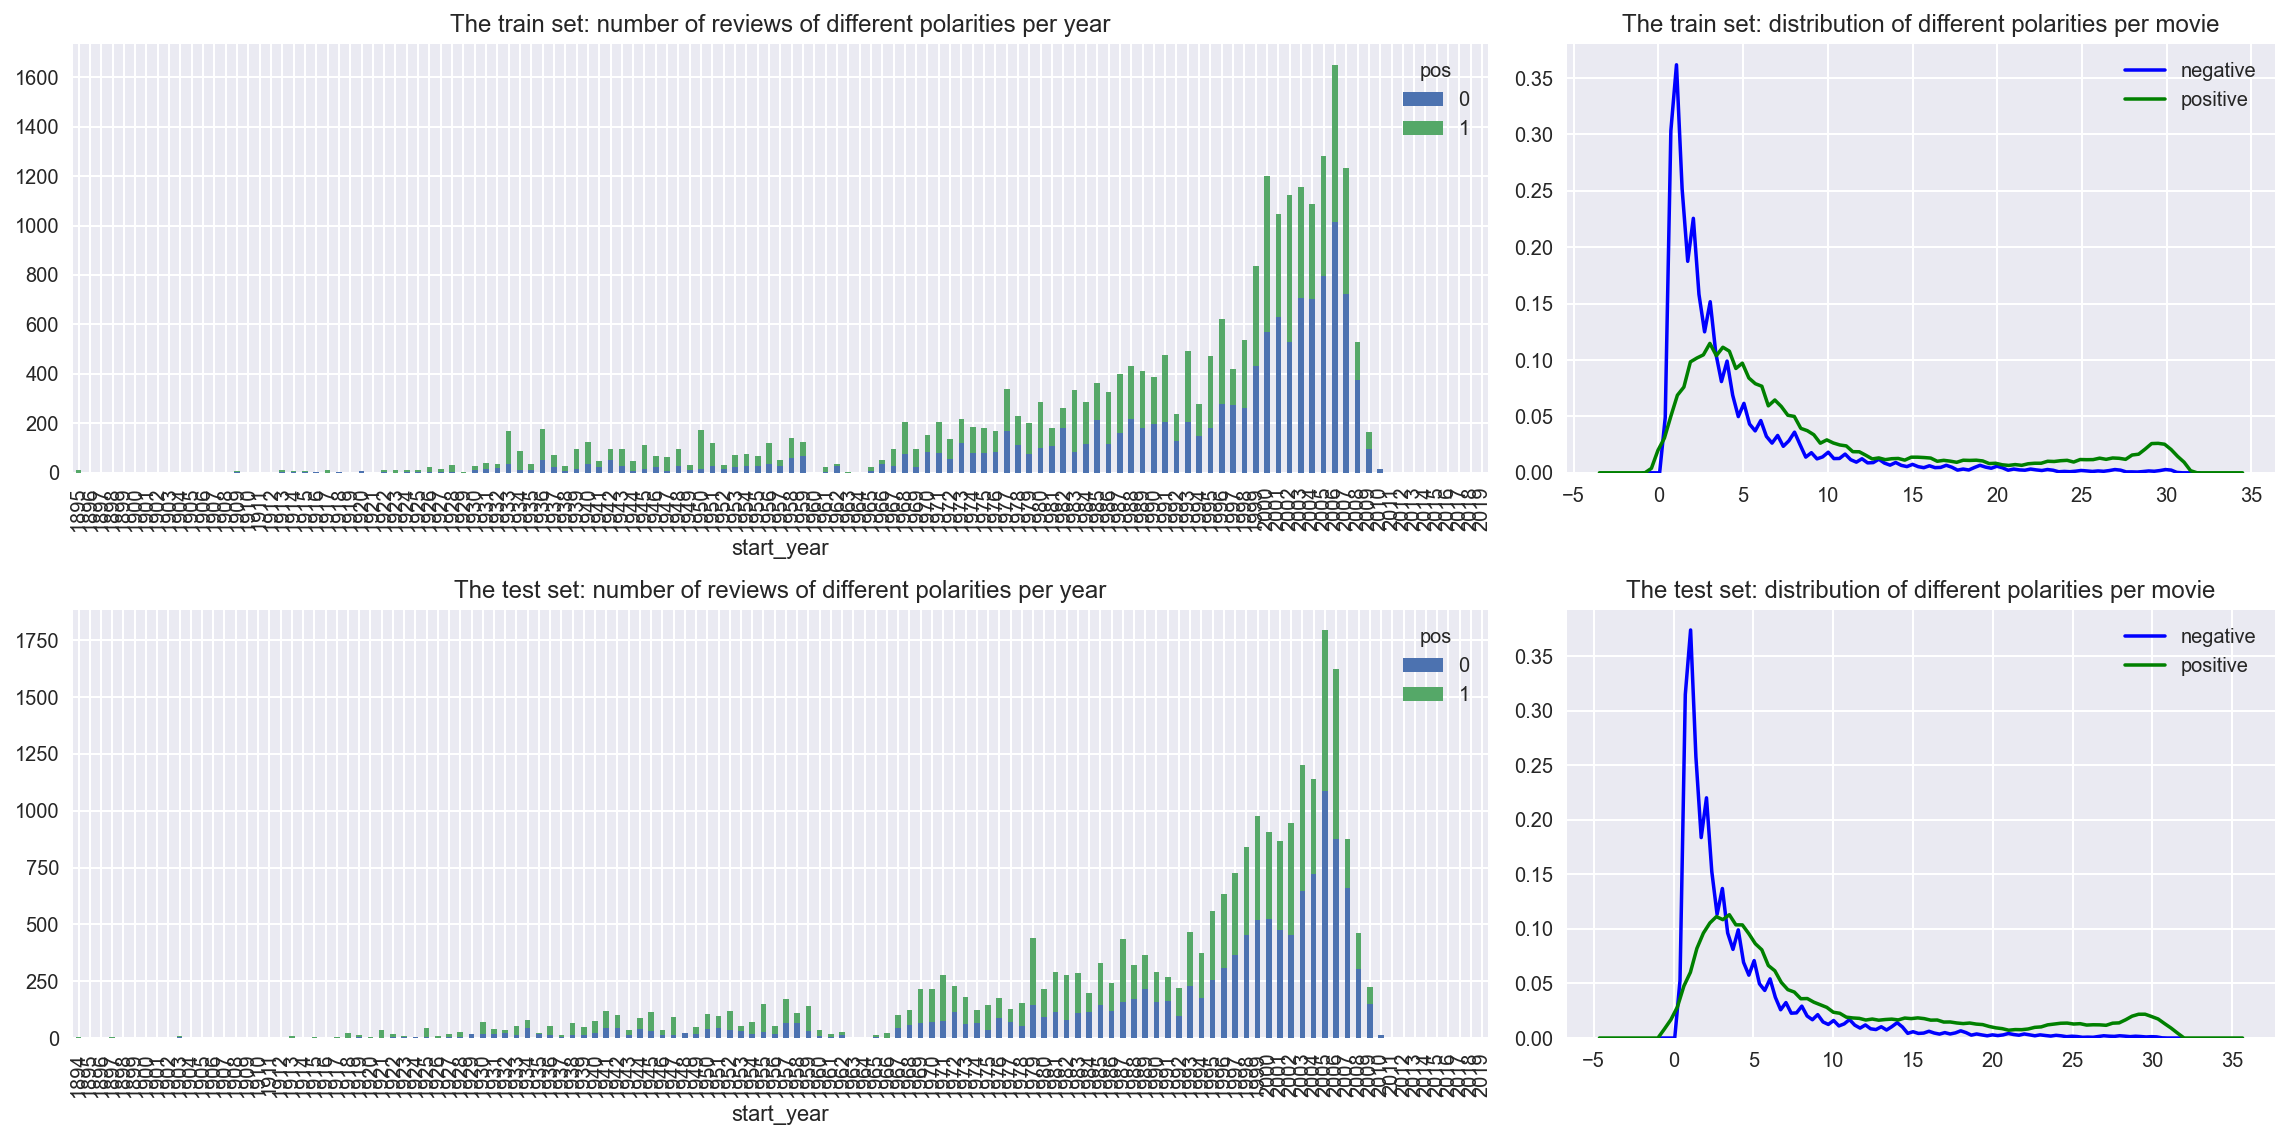

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))
# fig = plt.figure(figsize=(16, 8), constrained_layout=True)

# gs = fig.add_gridspec(3, 2)
# ax1 = fig.add_subplot(gs[0, :-1])
# ax2 = fig.add_subplot(gs[0, -1])
# ax3 = fig.add_subplot(gs[1, :-1])
# ax4 = fig.add_subplot(gs[1, -1])

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

# Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [12]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

# Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [13]:
df_reviews['review_norm'] = df_reviews['review'].str.lower().str.replace('[^a-zA-Z]', ' ')

# Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


# Model 0 - Constant

          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50


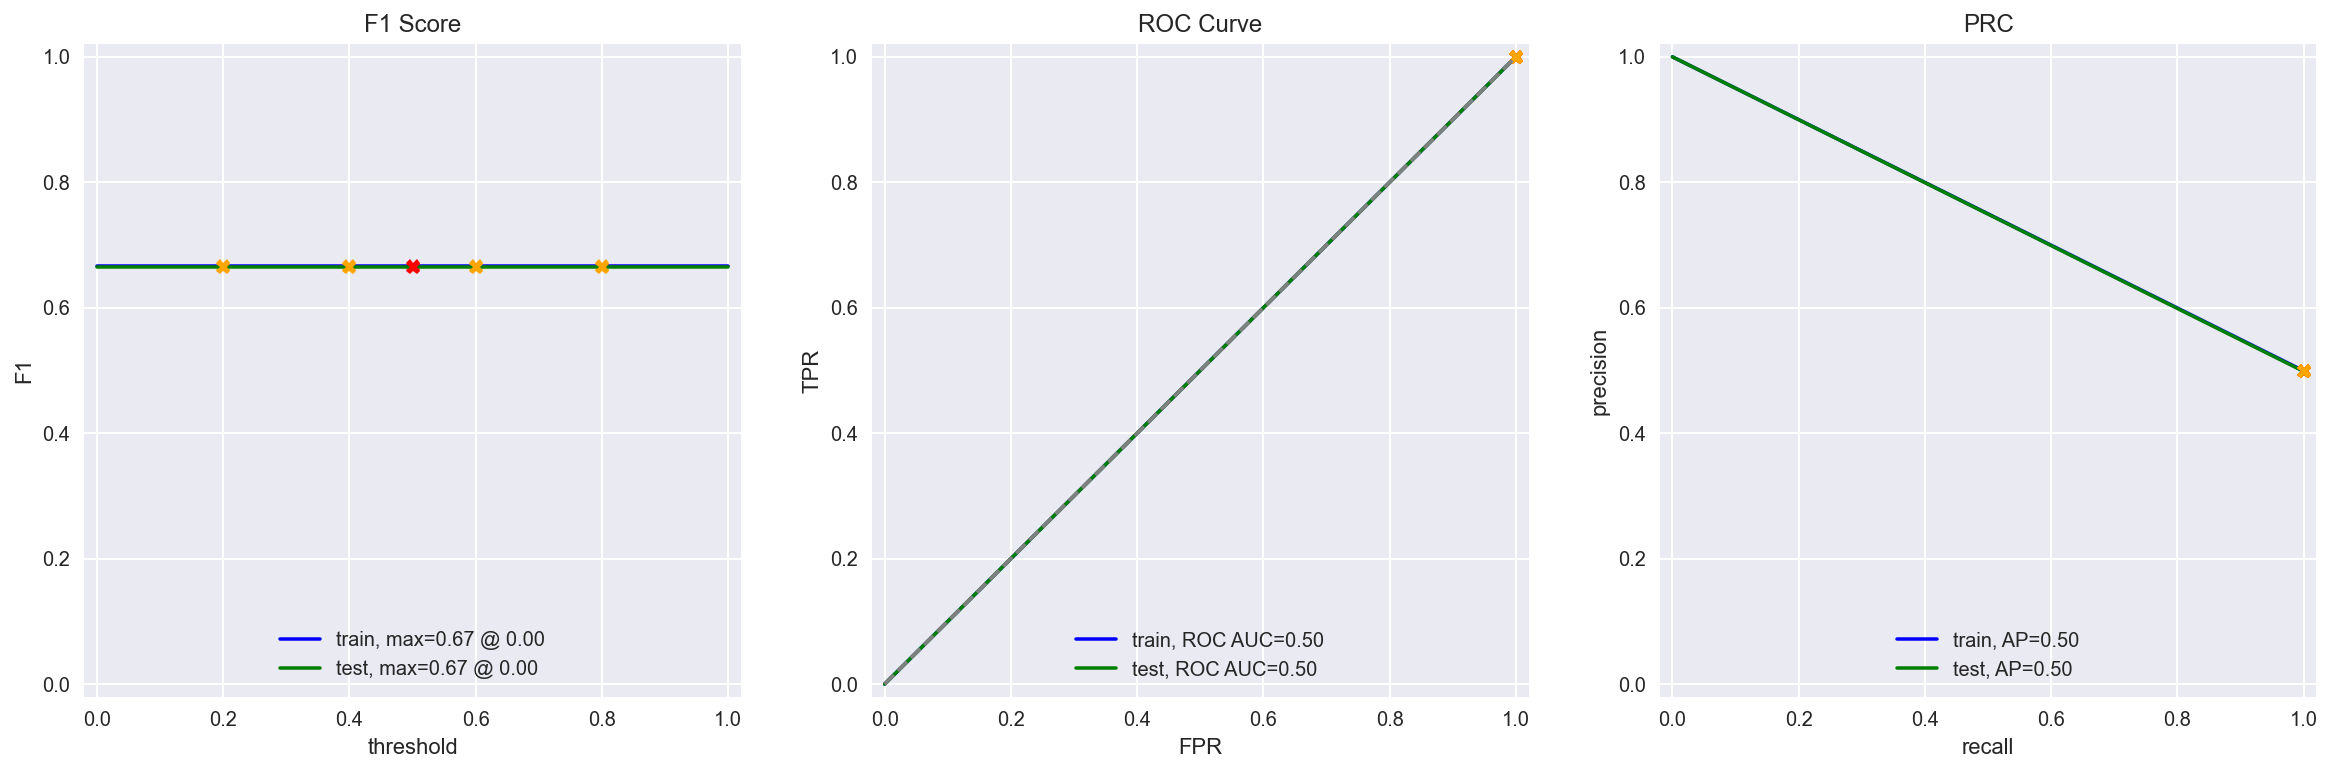

In [16]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='constant', constant=1)
#dummy_clf = DummyClassifier(strategy='most_frequent')

model_0 = dummy_clf.fit(X=df_reviews_train, y=train_target)

evaluate_model(model_0, np.empty(len(train_target)), train_target, np.empty(len(test_target)), test_target)

# Model 1 - NLTK, TF-IDF and LR

### TF-IDF

In [17]:
import nltk

#nltk.download('wordnet')
#nltk.download('stopwords')

from nltk.corpus import stopwords

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stopwords.words('english'), lowercase=True)

In [19]:
train_features = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
print(train_features.shape)

(23796, 71531)


In [20]:
test_features = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])
print(train_features.shape)

(23796, 71531)


In [21]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression()

model_1.fit(train_features, train_target)

LogisticRegression()

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


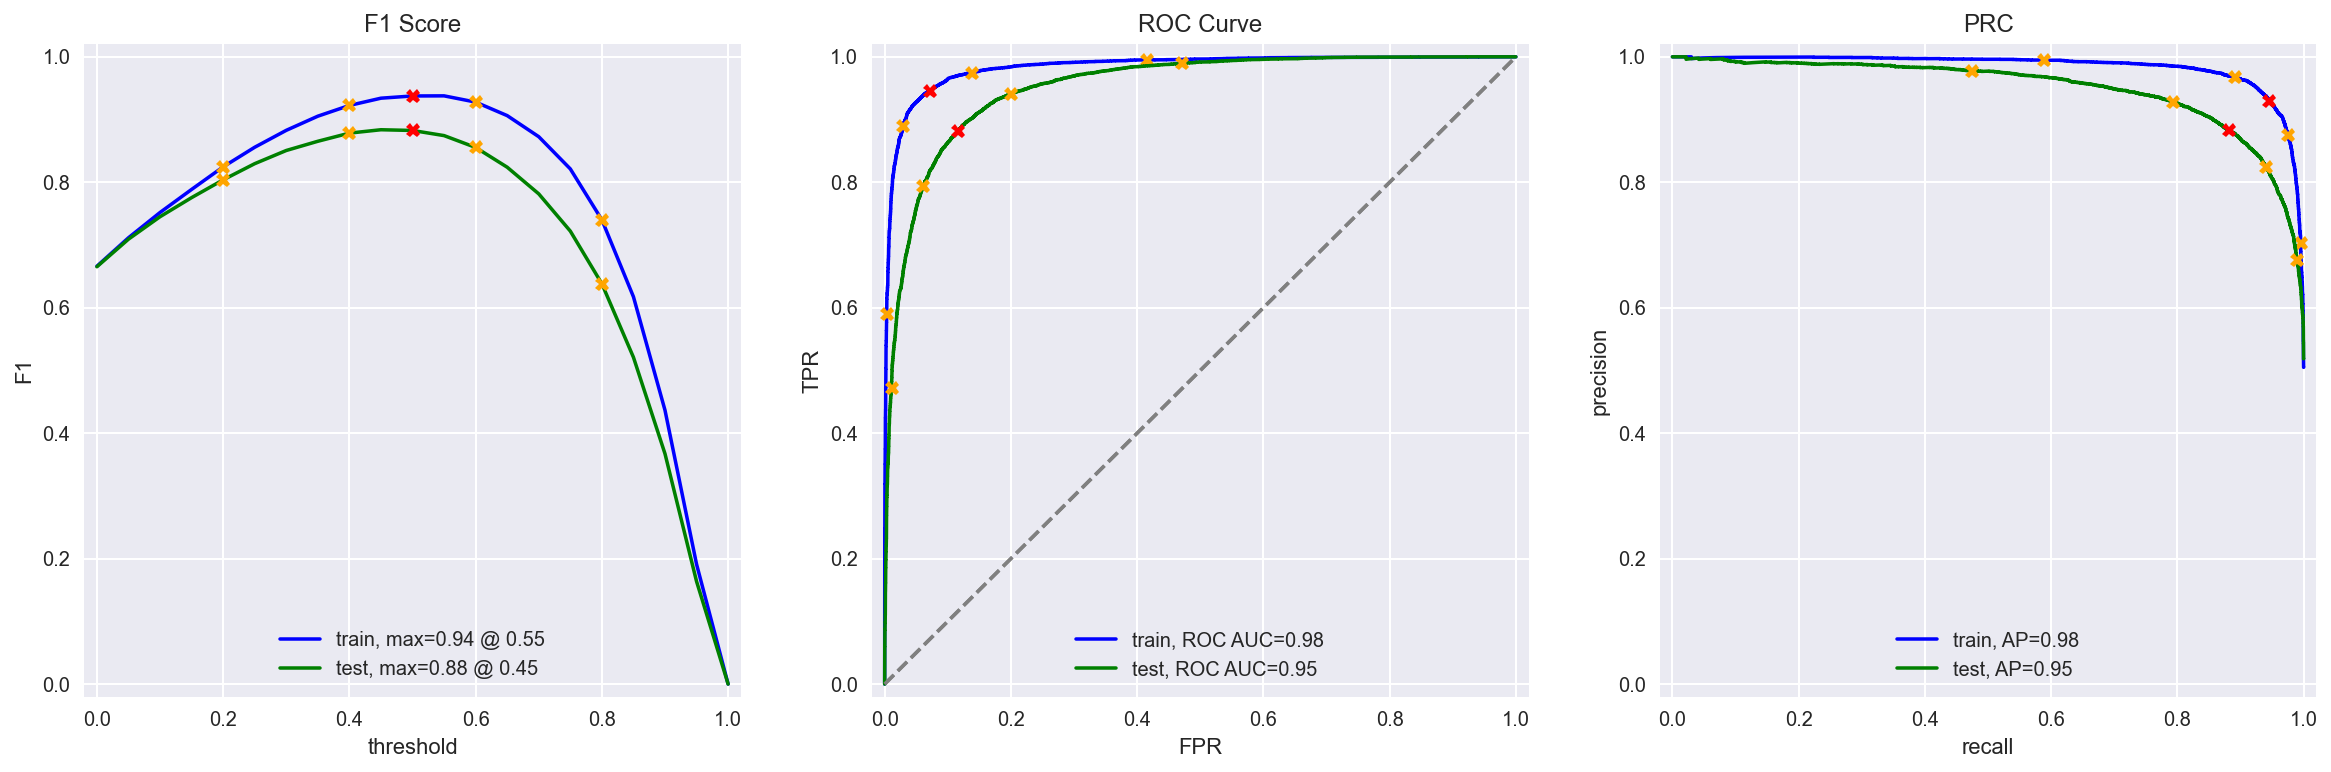

In [22]:
evaluate_model(model_1, train_features, train_target, test_features, test_target)

# Model 3 - spaCy, TF-IDF and LR

In [23]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [29]:
df_reviews_train['review_tokenized_3'] = df_reviews_train['review_norm'].progress_apply(lambda x: text_preprocessing_3(x))

In [30]:
df_reviews_test['review_tokenized_3'] = df_reviews_test['review_norm'].progress_apply(lambda x: text_preprocessing_3(x))

In [31]:
df_reviews_train['review_tokenized_3'].sample(5)

32915    i haven t see all of jess franco s movie   i h...
32443    what a wonderful   fanciful movie   stardust  ...
28536    taiwanese director ang lee   whose previous fi...
41495    i be an usherette in an old theater in norther...
13711    i see a preview of freebird at the isle of man...
Name: review_tokenized_3, dtype: object

In [32]:
df_reviews_test['review_tokenized_3'].sample(5)

27454    this film tell the true story of escape black ...
23945    of course   really experienced reviewer who li...
35237    this be one of those movie where i just want t...
42702    the connection with james dean in a short plan...
19455    -PRON- s too bad these guy   the so call judge...
Name: review_tokenized_3, dtype: object

In [33]:
tfidf_vectorizer_3 = TfidfVectorizer()

In [34]:
train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_tokenized_3'])
print(train_features_3.shape)

(23796, 60464)


In [35]:
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_tokenized_3'])
print(train_features_3.shape)

(23796, 60464)


In [36]:
from sklearn.linear_model import LogisticRegression

model_3 = LogisticRegression()

model_3.fit(train_features_3, train_target)

LogisticRegression()

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


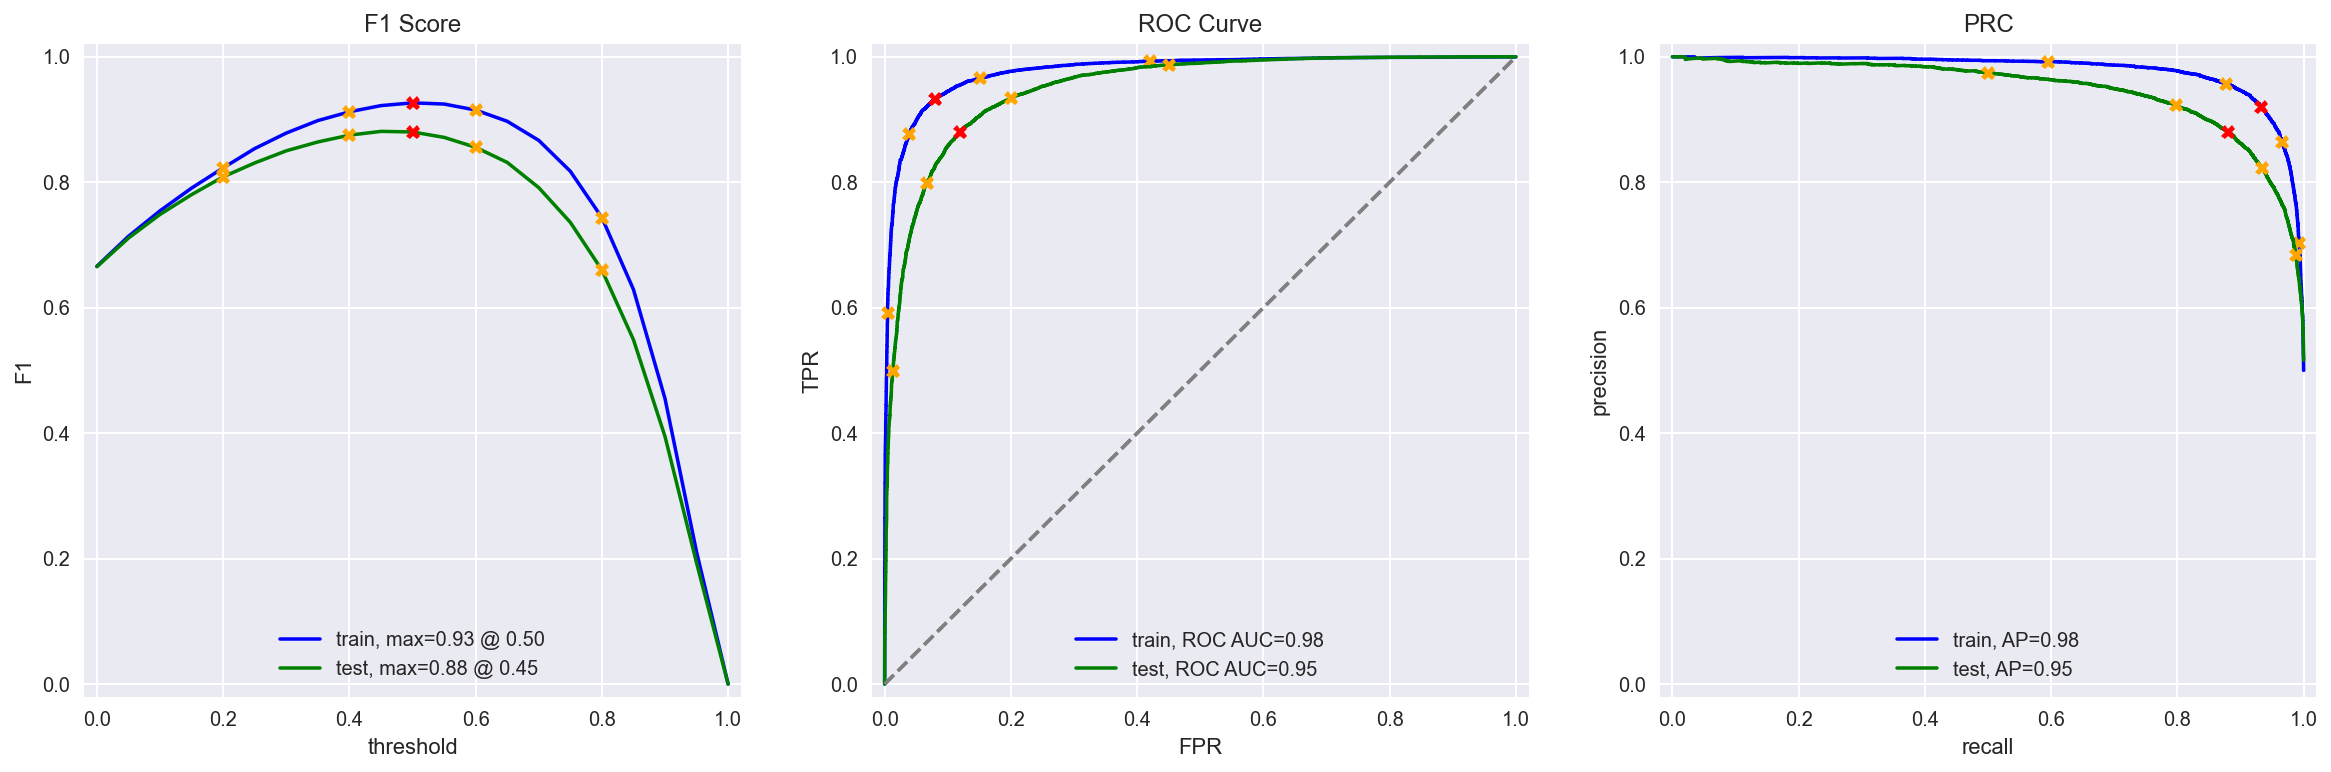

In [37]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

# Model 4 - spaCy, TF-IDF and LGBMClassifier

In [38]:
%%time

from lightgbm import LGBMClassifier

model_4 = LGBMClassifier(learning_rate=.1)

model_4.fit(train_features_3, train_target)

Wall time: 8.97 s


          train  test
Accuracy   0.92  0.86
F1         0.92  0.86
APS        0.98  0.94
ROC AUC    0.98  0.94


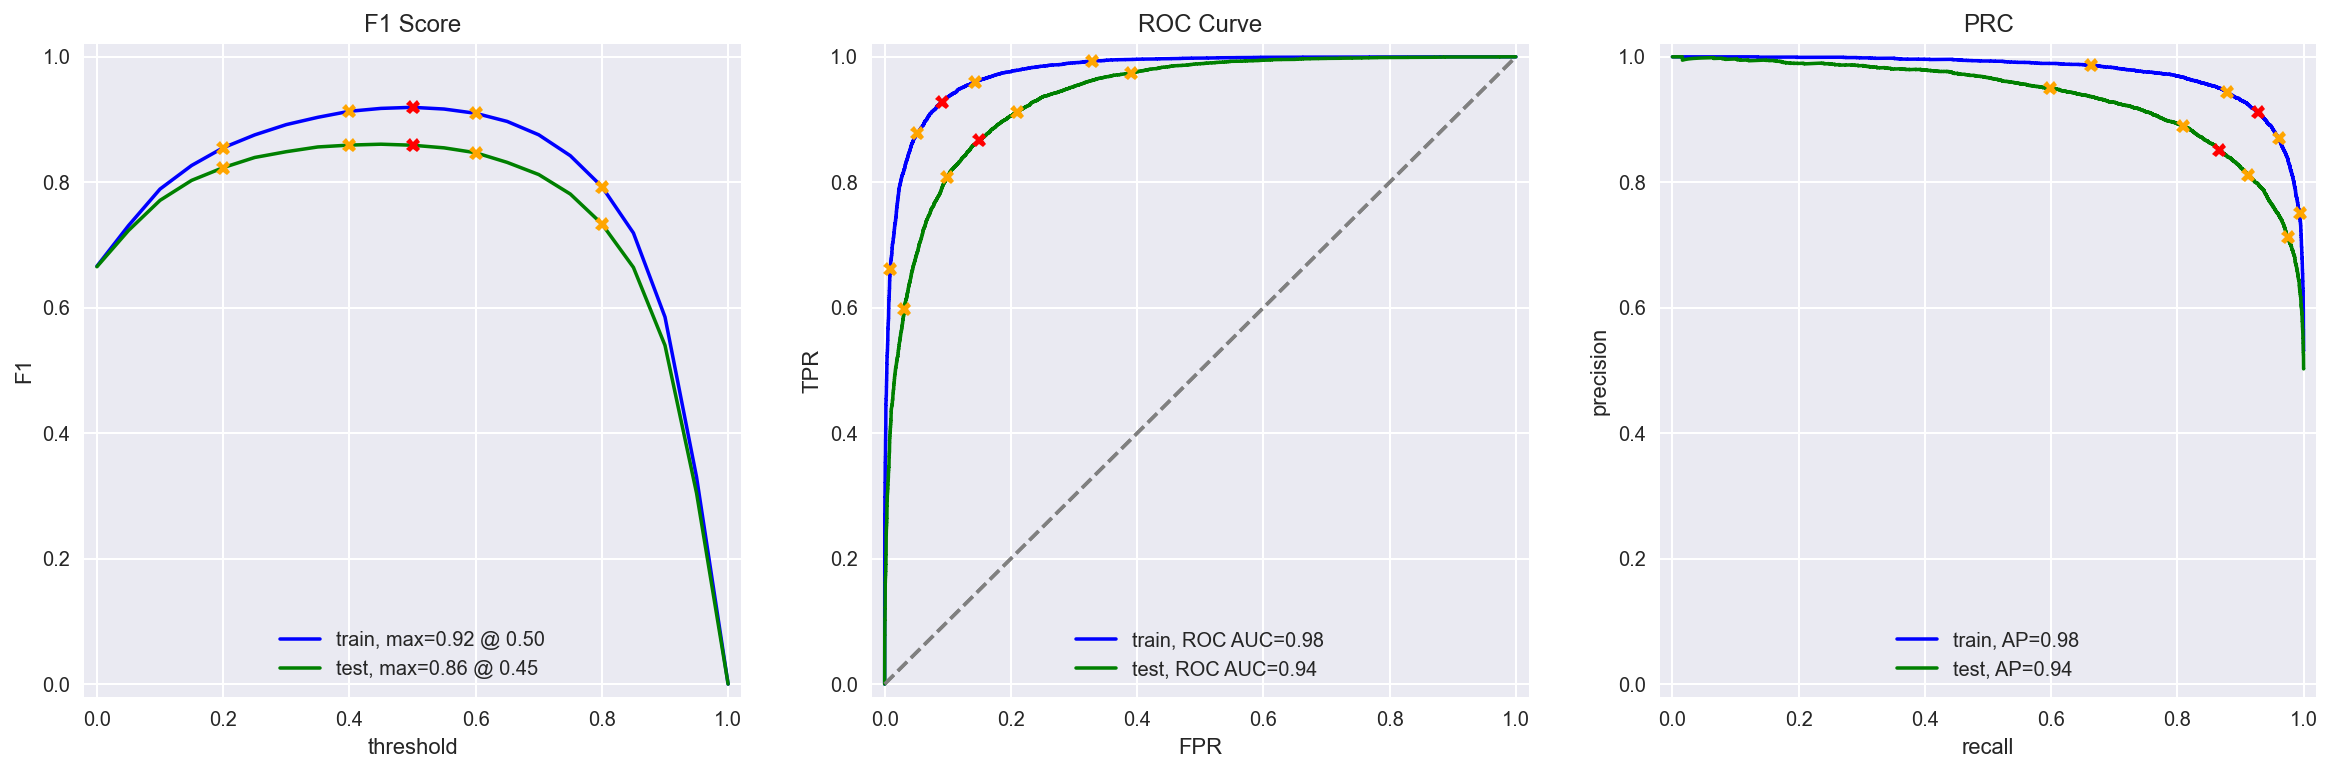

In [39]:
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)

#  Model 9 - BERT

In [40]:
import torch
import transformers

I0811 10:48:37.090890  2624 file_utils.py:39] PyTorch version 1.4.0 available.
I0811 10:48:38.398918  2624 file_utils.py:55] TensorFlow version 2.3.0 available.


In [41]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

I0811 10:48:39.133543  2624 tokenization_utils_base.py:1254] loading file https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-vocab.txt from cache at C:\Users\Dmitry/.cache\torch\transformers\26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084
I0811 10:48:39.698511  2624 configuration_utils.py:264] loading configuration file https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-config.json from cache at C:\Users\Dmitry/.cache\torch\transformers\4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517
I0811 10:48:39.699511  2624 configuration_utils.py:300] Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,


In [42]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    for input_text in tqdm(texts, disable=disable_progress_bar):
        ids = tokenizer.encode(input_text.lower(), add_special_tokens=True, truncation=True, max_length=max_length)
        padded = np.array(ids + [0]*(max_length - len(ids)))
        attention_mask = np.where(padded != 0, 1, 0)
        ids_list.append(padded)
        attention_mask_list.append(attention_mask)
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')
    
    # gettings embeddings in batches

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [43]:
# Attention! Running BERT for thousands of texts may take long run on CPU, several hours
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')


Using the cuda device.


In [44]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(23796,)
(23796, 768)
(23796,)


In [45]:
# Attention! Running BERT for thousands of texts may take long run on CPU, several hours
test_features_9 = BERT_text_to_embeddings(df_reviews_test['review_norm'], force_device='cuda')


Using the cuda device.


In [46]:
print(df_reviews_test['review_norm'].shape)
print(test_features_9.shape)
print(test_target.shape)

(23535,)
(23535, 768)
(23535,)


In [47]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

In [48]:
from sklearn.linear_model import LogisticRegression

model_9 = LogisticRegression(max_iter=1000)

model_9.fit(train_features_9, train_target)

LogisticRegression(max_iter=1000)

          train  test
Accuracy   0.88  0.86
F1         0.88  0.86
APS        0.95  0.94
ROC AUC    0.95  0.94


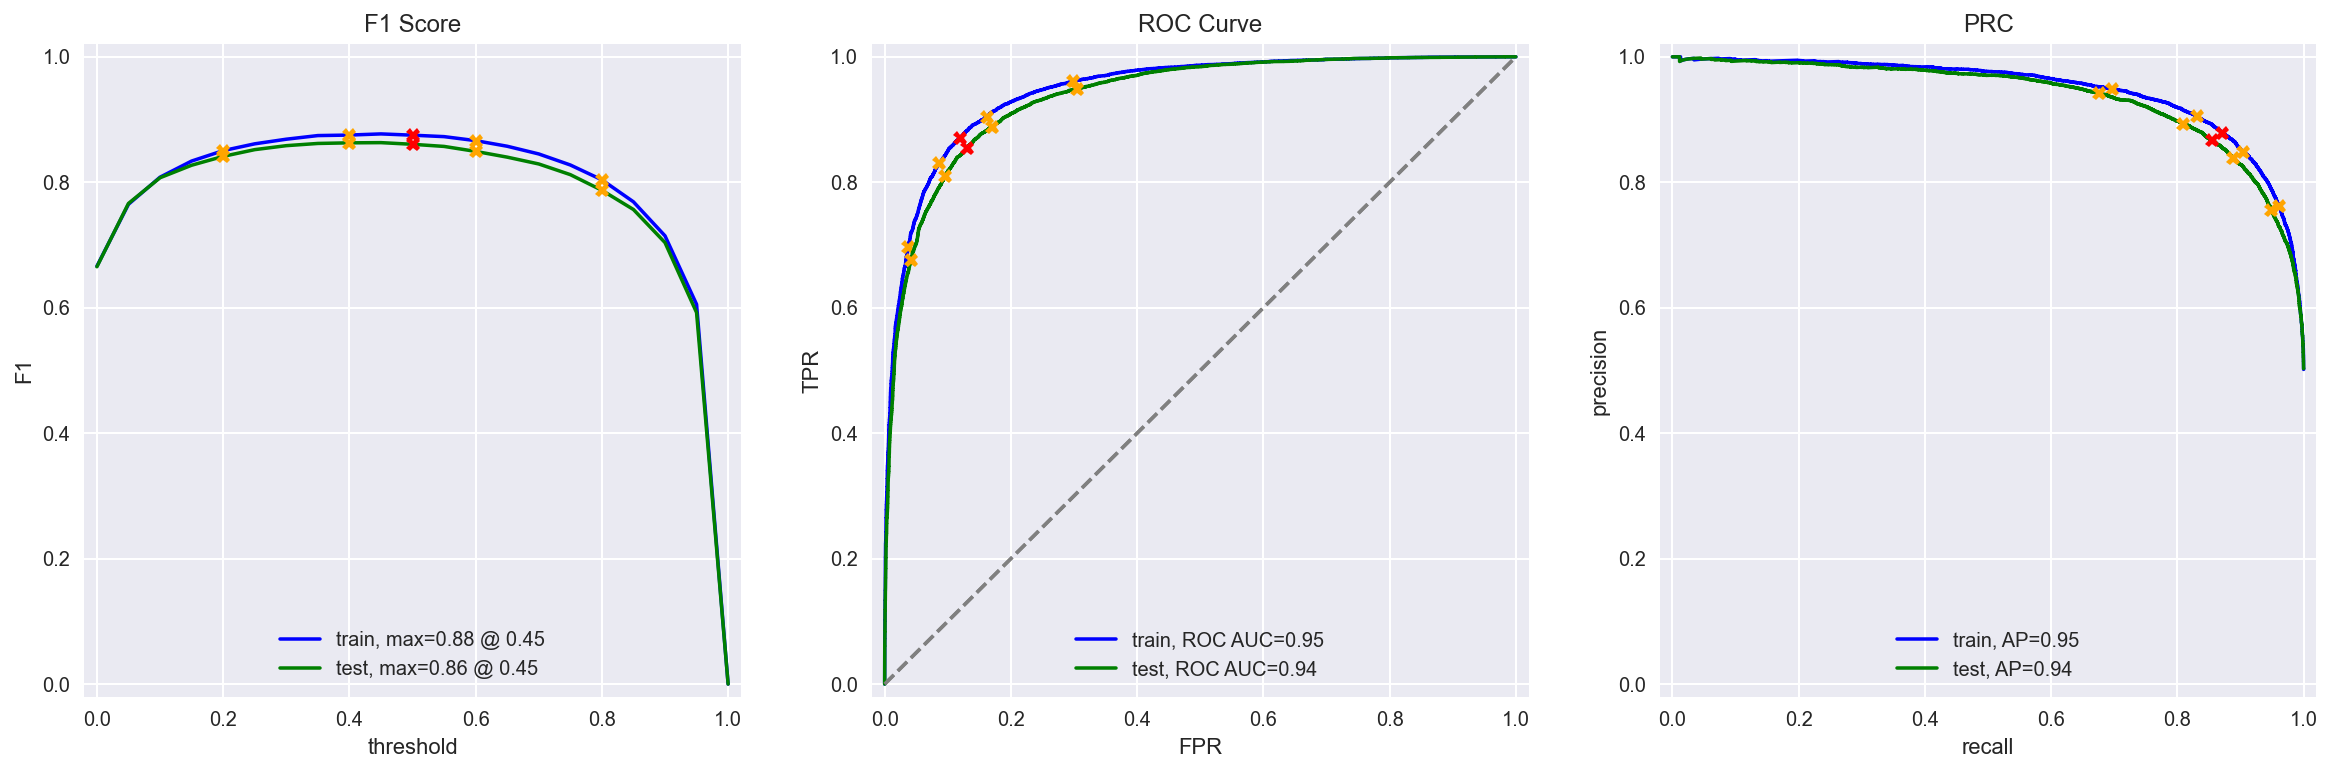

In [49]:
evaluate_model(model_9, train_features_9, train_target, test_features_9, test_target)

# My Reviews

In [52]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].str.lower().str.replace('[^a-zA-Z]', ' ')

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middl...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good writ...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a singl...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i real...


## Model 1

In [56]:
texts = my_reviews['review_norm']

my_reviews_features_1 = tfidf_vectorizer_1.transform(texts)
my_reviews_pred_prob = model_1.predict_proba(my_reviews_features_1)[:, 1]
my_reviews_pred = model_1.predict(my_reviews_features_1)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')

0.14  0:  i did not simply like it  not my kind of movie 
0.16  0:  well  i was bored and felt asleep in the middle of the movie 
0.54  1:  i was really fascinated with the movie
0.11  0:  even the actors looked really old and disinterested  and they got paid to be in the movie  what a so
0.31  0:  i didn t expect the reboot to be so good  writers really cared about the source material
0.47  0:  the movie had its upsides and downsides  but i feel like overall it s a decent flick  i could see my
0.04  0:  what a rotten attempt at a comedy  not a single joke lands  everyone acts annoying and loud  even ki
0.82  1:  launching on netflix was a brave move   i really appreciate being able to binge on episode after epi


## Model 3

In [58]:
texts = my_reviews['review_norm']

my_reviews_features_3 = tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x)))
my_reviews_pred_prob = model_3.predict_proba(my_reviews_features_3)[:, 1]
my_reviews_pred = model_3.predict(my_reviews_features_3)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')

0.18  0:  i did not simply like it  not my kind of movie 
0.25  0:  well  i was bored and felt asleep in the middle of the movie 
0.46  0:  i was really fascinated with the movie
0.17  0:  even the actors looked really old and disinterested  and they got paid to be in the movie  what a so
0.19  0:  i didn t expect the reboot to be so good  writers really cared about the source material
0.74  1:  the movie had its upsides and downsides  but i feel like overall it s a decent flick  i could see my
0.04  0:  what a rotten attempt at a comedy  not a single joke lands  everyone acts annoying and loud  even ki
0.87  1:  launching on netflix was a brave move   i really appreciate being able to binge on episode after epi


## Model 4

In [59]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_features_4 = tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x)))
my_reviews_pred_prob = model_4.predict_proba(my_reviews_features_4)[:, 1]
my_reviews_pred = model_4.predict(my_reviews_features_4)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')

0.72  1:  i did not simply like it  not my kind of movie 
0.55  1:  well  i was bored and felt asleep in the middle of the movie 
0.59  1:  i was really fascinated with the movie
0.63  1:  even the actors looked really old and disinterested  and they got paid to be in the movie  what a so
0.68  1:  i didn t expect the reboot to be so good  writers really cared about the source material
0.82  1:  the movie had its upsides and downsides  but i feel like overall it s a decent flick  i could see my
0.26  0:  what a rotten attempt at a comedy  not a single joke lands  everyone acts annoying and loud  even ki
0.75  1:  launching on netflix was a brave move   i really appreciate being able to binge on episode after epi


## Model 9

In [60]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]
my_reviews_pred = model_9.predict(my_reviews_features_9)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')

0.21  0:  i did not simply like it  not my kind of movie 
0.01  0:  well  i was bored and felt asleep in the middle of the movie 
0.99  1:  i was really fascinated with the movie
0.00  0:  even the actors looked really old and disinterested  and they got paid to be in the movie  what a so
0.21  0:  i didn t expect the reboot to be so good  writers really cared about the source material
0.94  1:  the movie had its upsides and downsides  but i feel like overall it s a decent flick  i could see my
0.09  0:  what a rotten attempt at a comedy  not a single joke lands  everyone acts annoying and loud  even ki
0.96  1:  launching on netflix was a brave move   i really appreciate being able to binge on episode after epi


# Conclusions

- There are slightly different way to turn text into tokens and lemmas.
- There are different way to turn texts into vectors.
- The simple model TF-IDF + LogisticRegression provides a good quality given the target metrics.
- Lemmatization with spaCy does not seem to help much.
- BERT takes a lot of time on CPU but much less on GPU.
- Classification model based on language model (BERT) shows metrics (accuracy, F1 etc) is of similar values to less complex models but seems to be more dividing (the probabilities are more 'polarized') and less prone to overfitting.

# Check List

- [x]  Notebook was opened
- [ ]  The text data is loaded and pre-processed for vectorization
- [ ]  The text data is transformed to vectors
- [ ]  Models are trained and tested
- [ ]  The metric's threshold is reached
- [ ]  All the code cells are arranged in the order of their execution
- [ ]  All the code cells can be executed without errors
- [ ]  There are conclusions